In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
from xgboost import XGBRegressor, plot_tree

In [4]:
# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_excel("data1319.xlsx")

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [5]:
# -----------------------------
# 2. Define target
# -----------------------------
y = df["share"]

In [6]:
# -----------------------------
# 3. Define features (exclude mo, year, model)
# -----------------------------
exclude_cols = ["share", "mo", "year", "model"]
X = df.drop(columns=exclude_cols)

In [7]:
# -----------------------------
# 4. Encode categorical features
# -----------------------------
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [8]:
# -----------------------------
# 5. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
# -----------------------------
# 6. Define XGBoost model
# -----------------------------
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [10]:
# -----------------------------
# 7. Train model
# -----------------------------
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
# -----------------------------
# 8. Predictions
# -----------------------------
predictions = model.predict(X_test)

In [12]:
# -----------------------------
# 9. Evaluate model
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [13]:
print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.21843448484527936
R²: 0.9210216568353633


In [14]:
# -----------------------------
# 10. Predict new data
# -----------------------------
# Example: predict the first 5 rows
new_predictions = model.predict(X.iloc[:5])
print("Example predictions:")
print(new_predictions)

Example predictions:
[0.25911665 1.3534656  1.8440958  0.31664544 0.22869262]


In [15]:
# -----------------------------
# 11. K-Fold cross validation
# -----------------------------
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("R2 scores:", scores)
print("Mean R2:", np.mean(scores))

R2 scores: [0.63870009 0.73130653 0.82813247 0.83663908 0.70820518]
Mean R2: 0.7485966696152588


In [16]:
# =============================
# 12. Explain the model
# =============================
booster = model.get_booster()

In [17]:
# ---- 12a. Print all trees ----
tree_dumps = booster.get_dump(with_stats=True)
for i, tree in enumerate(tree_dumps):
    print(f"\n===== Tree {i} =====\n")
    print(tree)


===== Tree 0 =====

0:[comfort<4] yes=1,no=2,missing=2,gain=70.0284195,cover=602
	1:[safety<4] yes=3,no=4,missing=4,gain=129.121841,cover=409
		3:[brand<4] yes=7,no=8,missing=8,gain=11.519083,cover=278
			7:[finish<3] yes=13,no=14,missing=14,gain=20.4783802,cover=175
				13:[rugged<3] yes=19,no=20,missing=20,gain=3.40293884,cover=101
					19:leaf=0.0159081351,cover=40
					20:[style<2] yes=25,no=26,missing=26,gain=0.829520941,cover=61
						25:leaf=0.00649479544,cover=47
						26:leaf=-0.00170034019,cover=14
				14:[economy<3] yes=21,no=22,missing=22,gain=6.24078369,cover=74
					21:leaf=-0.0166718047,cover=54
					22:[style<3] yes=27,no=28,missing=28,gain=3.92170286,cover=20
						27:leaf=0.0104113715,cover=15
						28:leaf=-0.0180584919,cover=5
			8:[economy<3] yes=15,no=16,missing=16,gain=0.943132401,cover=103
				15:leaf=-0.0147011904,cover=59
				16:[brand<5] yes=23,no=24,missing=24,gain=0.0245571136,cover=44
					23:leaf=-0.00710687367,cover=26
					24:leaf=-0.0099862013,cover=1

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

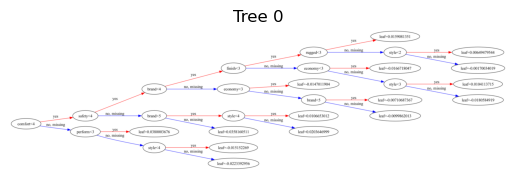

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

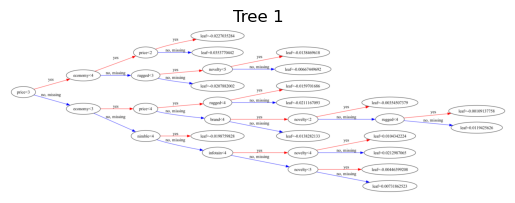

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

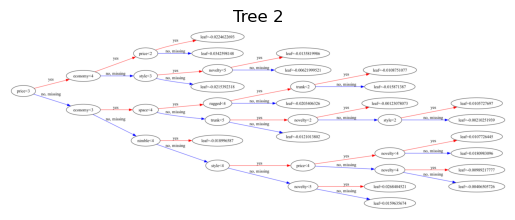

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

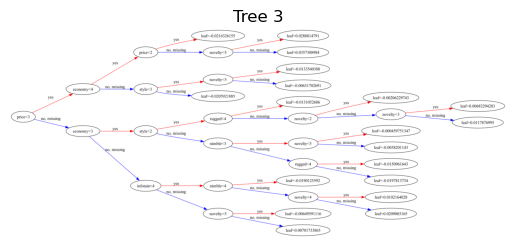

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

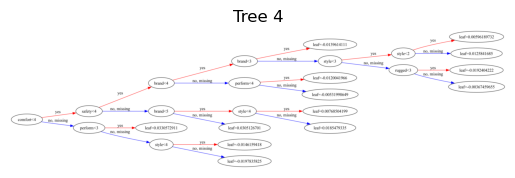

In [18]:
# ---- 12b. Plot the first few trees ----
N = min(5, len(tree_dumps))  # number of trees to visualize
for i in range(N):
    plt.figure(figsize=(20, 10))
    plot_tree(model, num_trees=i, rankdir='LR')
    plt.title(f"Tree {i}")
    plt.show()

In [19]:
# ---- 12c. Feature importance ----
importance = booster.get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print("\nFeature Importance (by gain):")
for feat, val in sorted_importance:
    print(f"{feat}: {val:.3f}")


Feature Importance (by gain):
price: 4.419
safety: 3.457
economy: 2.952
comfort: 1.141
perform: 0.699
nimble: 0.452
space: 0.391
infotain: 0.377
trunk: 0.272
finish: 0.227
rugged: 0.200
brand: 0.162
style: 0.148
features: 0.064
novelty: 0.060
versatile: 0.054


In [20]:
# ---- 12d. Summary figure highlighting top features ----
top_features = [feat for feat, _ in sorted_importance[:5]]  # top 5 features

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'price'),
  Text(1, 0, 'safety'),
  Text(2, 0, 'economy'),
  Text(3, 0, 'comfort'),
  Text(4, 0, 'perform'),
  Text(5, 0, 'nimble'),
  Text(6, 0, 'space'),
  Text(7, 0, 'infotain'),
  Text(8, 0, 'trunk'),
  Text(9, 0, 'finish'),
  Text(10, 0, 'rugged'),
  Text(11, 0, 'brand'),
  Text(12, 0, 'style'),
  Text(13, 0, 'features'),
  Text(14, 0, 'novelty'),
  Text(15, 0, 'versatile')])

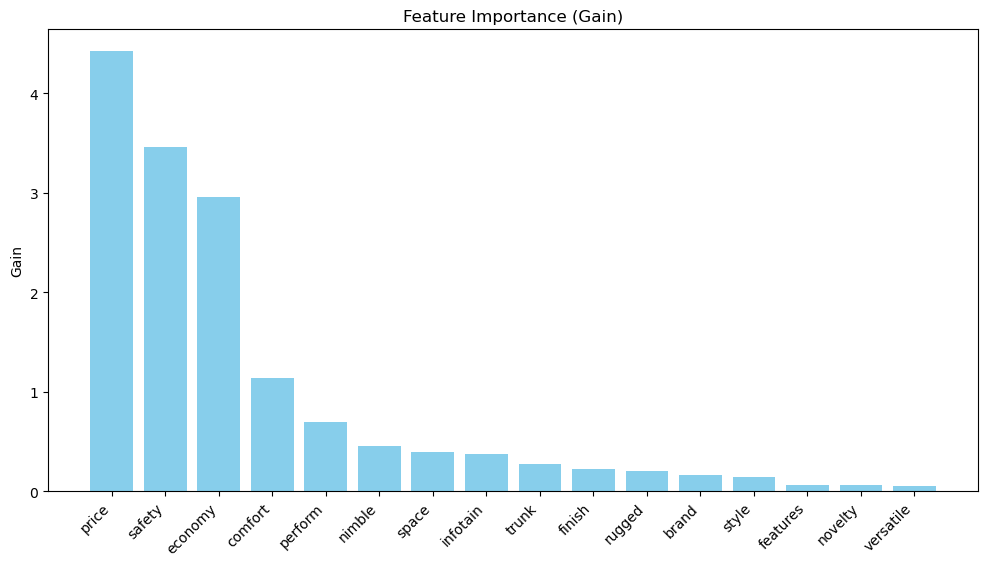

In [21]:
plt.figure(figsize=(12, 6))
plt.bar([feat for feat, _ in sorted_importance], [val for _, val in sorted_importance], color='skyblue')
plt.title("Feature Importance (Gain)")
plt.ylabel("Gain")
plt.xticks(rotation=45, ha='right')

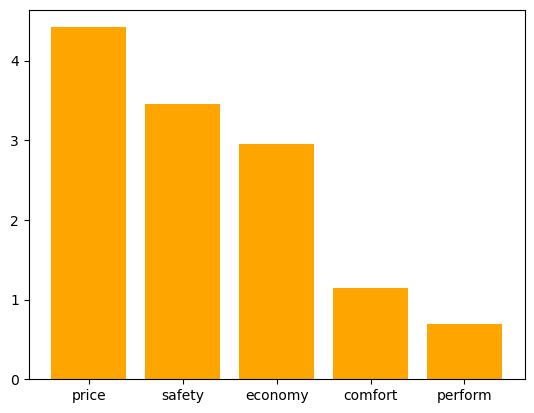

In [22]:
# Highlight top features in orange
for feat in top_features:
    plt.bar(feat, importance[feat], color='orange')

In [23]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

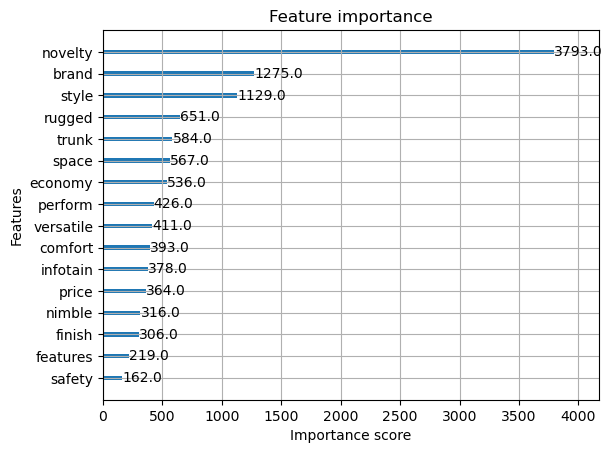

In [24]:
from xgboost import plot_importance
plot_importance(model)

In [25]:
# ---- 13a. Define base XGBoost model
xgb = XGBRegressor(random_state=42)

In [27]:
# ---- 13b. GridSearchCV parameters
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.03, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)


In [ ]:
# ---- 13c. Run Grid Search
grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

# Best model
model = grid_search.best_estimator_

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters found:
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.7}

Best CV score:
0.8970025172214322


In [31]:
# ----- 13d. Get accuracies
from sklearn import metrics
def get_regression_metrics(X_train, X_test, y_train, y_test, model):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    metrics_dict = {
        "train R2": metrics.r2_score(y_train, y_train_pred),
        "test R2": metrics.r2_score(y_test, y_test_pred),
        "train RMSE": np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)),
        "test RMSE": np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)),
        "train MAE": metrics.mean_absolute_error(y_train, y_train_pred),
        "test MAE": metrics.mean_absolute_error(y_test, y_test_pred)
    }
    return metrics_dict

# Call the function
get_regression_metrics(X_train, X_test, y_train, y_test, model)


{'train R2': 0.9085539941567968,
 'test R2': 0.9209987166303581,
 'train RMSE': np.float64(0.23952198847183606),
 'test RMSE': np.float64(0.21846620599720096),
 'train MAE': 0.15259517620424895,
 'test MAE': 0.1588651736508773}